# FWH Rotor Acoustic Simulator — Audio Generator

Generate drone rotor noise from a rotor-speed (RPS) timeseries using the Ffowcs-Williams Hawkings (FWH) acoustic solver.

**Inputs:**
- RPS timeseries (Hz) — from DREGON-LM dataset or custom array
- Rotor geometry (radius, chord, twist, blades)
- Observer position

**Outputs:**
- Acoustic pressure waveform
- Playable audio
- Spectrogram and spectrum plots

The simulator uses Farassat 1A formulation with BEMT aerodynamics.

In [ ]:
from utils.paths import get_data_path


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.interpolate import interp1d

# Add project root to path
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from fwh_rotor_sim.geometry import Blade, Rotor  # noqa: E402
from fwh_rotor_sim.plotting import plot_blade_geometry, plot_rotor_top_view  # noqa: E402
from fwh_rotor_sim.solver import FWHRotorSolver  # noqa: E402

print("FWH rotor simulator loaded.")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")

FWH rotor simulator loaded.
PyTorch version: 2.7.0+cu126
NumPy version: 2.2.5


## 1. Load or Define RPS Timeseries

You can either:
1. **Load from DREGON-LM** — pick a sample and a rotor index
2. **Define custom RPS** — create your own speed profile

RPS shape: `(4, N)` for 4 rotors at ~1000 Hz sample rate.

Loaded RPS: (4, 7814), duration=7.81s
RPS range: [69.0, 88.1] Hz


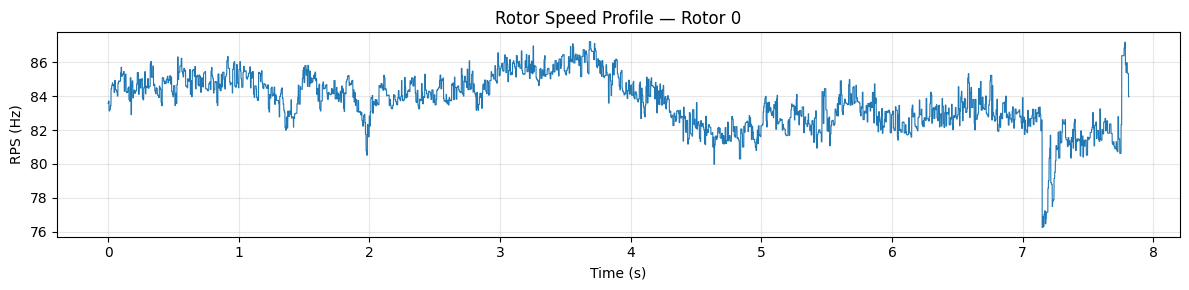

Selected RPS: mean=83.7 Hz, std=1.6 Hz


In [2]:
# Configuration
DATASET_PATH = PROJECT_ROOT / "datasets" / "DREGON-LM" / "valid"
SAMPLE_NAME = "sample_00000"   # Change to any sample in the dataset
RPS_SR = 1000.0                   # Native RPS sample rate (Hz)
AUDIO_SR = 16000                  # Output audio sample rate (Hz)

# Load RPS data
rps_path = DATASET_PATH / SAMPLE_NAME / "rps.npy"
if rps_path.exists():
    rps_all = np.load(rps_path)   # shape: (4, N)
    print(f"Loaded RPS: {rps_all.shape}, duration={rps_all.shape[1]/RPS_SR:.2f}s")
    print(f"RPS range: [{rps_all.min():.1f}, {rps_all.max():.1f}] Hz")
else:
    print(f"RPS file not found: {rps_path}")
    print("Using synthetic RPS profile instead.")
    # Synthetic: sinusoidal variation between 60-100 Hz over 5 seconds
    t_rps = np.arange(int(5.0 * RPS_SR)) / RPS_SR
    rps_all = np.stack([
        80 + 15 * np.sin(2 * np.pi * 2.0 * t_rps),
        80 + 15 * np.sin(2 * np.pi * 2.0 * t_rps + np.pi/4),
        80 + 15 * np.sin(2 * np.pi * 2.0 * t_rps + np.pi/2),
        80 + 15 * np.sin(2 * np.pi * 2.0 * t_rps + 3*np.pi/4),
    ]).astype(np.float32)

# Pick which rotor to simulate (0-3) or average all 4
ROTOR_IDX = 0        # 0=front-left, 1=front-right, 2=rear-right, 3=rear-left (DREGON convention)
AVERAGE_ALL = False    # Set True to average all 4 rotors into a single speed profile

rps_native = rps_all.mean(axis=0) if AVERAGE_ALL else rps_all[ROTOR_IDX]

# Plot the RPS profile
t_native = np.arange(len(rps_native)) / RPS_SR
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t_native, rps_native, lw=0.8)
ax.set_xlabel("Time (s)")
ax.set_ylabel("RPS (Hz)")
ax.set_title(f"Rotor Speed Profile — {'Average of 4 rotors' if AVERAGE_ALL else f'Rotor {ROTOR_IDX}'}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Selected RPS: mean={rps_native.mean():.1f} Hz, std={rps_native.std():.1f} Hz")

## 2. Configure Rotor Geometry

Adjust these parameters to match your drone. Defaults are for a small quadcopter (~6-inch prop).

DREGON geometry loaded:
  Microphones: 8  (array underneath drone)
  Rotors:      4  (on top of drone arms)

Selected: Mic 0 + Rotor 0
  Mic position  (drone frame): [ 0.042   0.0615 -0.041 ]
  Rotor position (drone frame): [-0.15997339  0.17147339  0.1915    ]
  Observer rel. to rotor:      [0.20197339355945587, -0.10997339338064194, -0.23250000178813934]


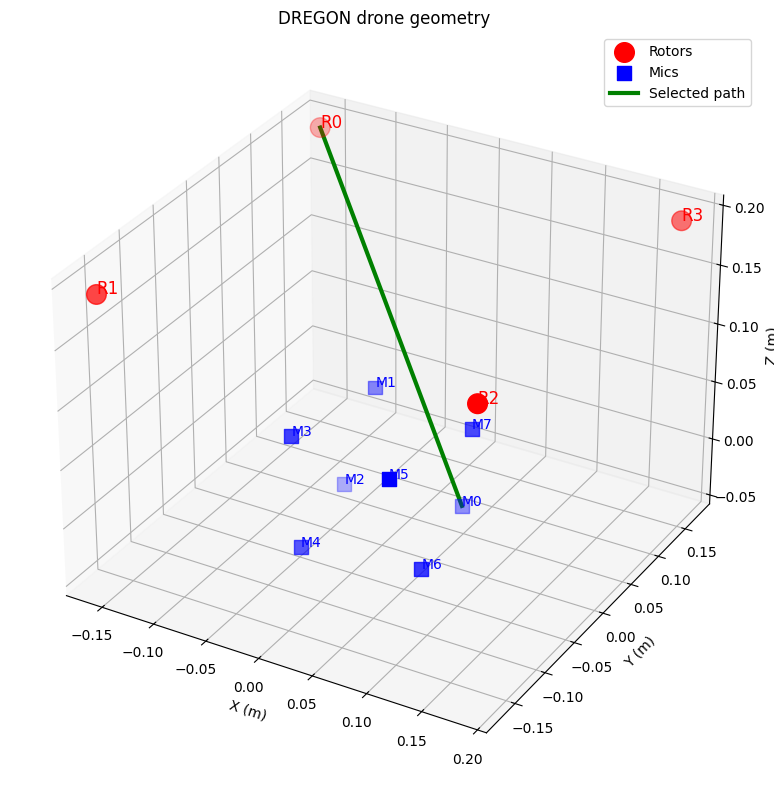

In [3]:
# ------------------------------------------------------------------------------
# DREGON microphone and rotor geometry
# ------------------------------------------------------------------------------
# Load from the raw DREGON dataset (plot_structure.m / coordinates.mat)
DREGON_DIR = PROJECT_ROOT / "data" / "DREGON"
coord_mat_path = DREGON_DIR / "coordinates.mat"
mic_txt_path = DREGON_DIR / "micPos.txt"

if coord_mat_path.exists():
    import scipy.io
    mat = scipy.io.loadmat(str(coord_mat_path))
    MIC_POSITIONS = mat["micPos"]          # (8, 3) in meters
    ROTOR_POSITIONS = mat["rotorsPos"]    # (4, 3) in meters
elif mic_txt_path.exists():
    # Fallback: parse micPos.txt manually
    txt = mic_txt_path.read_text()
    import re
    m = re.search(r'\[\s*([\s\S]*?)\s*\]', txt)
    rows = []
    for line in m.group(1).split(';'):
        line = re.sub(r'%.*', '', line)
        nums = re.findall(r'-?\d+\.?\d*', line)
        if len(nums) >= 3:
            rows.append([float(nums[0]), float(nums[1]), float(nums[2])])
    MIC_POSITIONS = np.array(rows)
    # Rotor positions from plot_structure.m logic
    r = 0.485 / 2
    angle = np.deg2rad(np.array([45, 135, 225, 315]) + 90)
    offset = np.array([0.0115, 0.0, 0.0])
    ROTOR_POSITIONS = np.stack([
        r * np.cos(angle), r * np.sin(angle), np.full(4, 0.1915)
    ], axis=1) + offset
else:
    raise FileNotFoundError(f"DREGON geometry not found at {DREGON_DIR}")

print("DREGON geometry loaded:")
print(f"  Microphones: {MIC_POSITIONS.shape[0]}  (array underneath drone)")
print(f"  Rotors:      {ROTOR_POSITIONS.shape[0]}  (on top of drone arms)")

# Select which microphone and rotor to simulate
# The observer position in the rotor's local frame = mic - rotor
MIC_IDX = 0       # 0-7 (microphone index)
# ROTOR_IDX = 0     # 0-3 (rotor index; DREGON: 0=FL, 1=FR, 2=RR, 3=RL approx), ALREADY SELECTED

OBSERVER_POS = torch.tensor(MIC_POSITIONS[MIC_IDX] - ROTOR_POSITIONS[ROTOR_IDX], dtype=torch.float32)

print(f"\nSelected: Mic {MIC_IDX} + Rotor {ROTOR_IDX}")
print(f"  Mic position  (drone frame): {MIC_POSITIONS[MIC_IDX]}")
print(f"  Rotor position (drone frame): {ROTOR_POSITIONS[ROTOR_IDX]}")
print(f"  Observer rel. to rotor:      {OBSERVER_POS.tolist()}")

# 3D visualization of the DREGON setup
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot rotors
ax.scatter(ROTOR_POSITIONS[:, 0], ROTOR_POSITIONS[:, 1], ROTOR_POSITIONS[:, 2],
           c='red', s=200, marker='o', label='Rotors')
for i, pos in enumerate(ROTOR_POSITIONS):
    ax.text(pos[0], pos[1], pos[2], f'R{i}', color='red', fontsize=12)

# Plot microphones
ax.scatter(MIC_POSITIONS[:, 0], MIC_POSITIONS[:, 1], MIC_POSITIONS[:, 2],
           c='blue', s=100, marker='s', label='Mics')
for i, pos in enumerate(MIC_POSITIONS):
    ax.text(pos[0], pos[1], pos[2], f'M{i}', color='blue', fontsize=10)

# Highlight selected pair
ax.plot([ROTOR_POSITIONS[ROTOR_IDX, 0], MIC_POSITIONS[MIC_IDX, 0]],
        [ROTOR_POSITIONS[ROTOR_IDX, 1], MIC_POSITIONS[MIC_IDX, 1]],
        [ROTOR_POSITIONS[ROTOR_IDX, 2], MIC_POSITIONS[MIC_IDX, 2]],
        'g-', lw=3, label='Selected path')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('DREGON drone geometry')
ax.legend()
plt.tight_layout()
plt.show()


Rotor geometry configured (APC 10x7 Thin Electric):
  Radius: 127.0 mm
  Hub radius: 9.53 mm
  Chord at 75%R: 16.4 mm
  Twist at 75%R: 16.7°
  Blades: 2
  Radial panels: 60
  Observer: [0.20197339355945587, -0.10997339338064194, -0.23250000178813934] m  (Mic 0 - Rotor 0)
  Sim SR: 16000 Hz


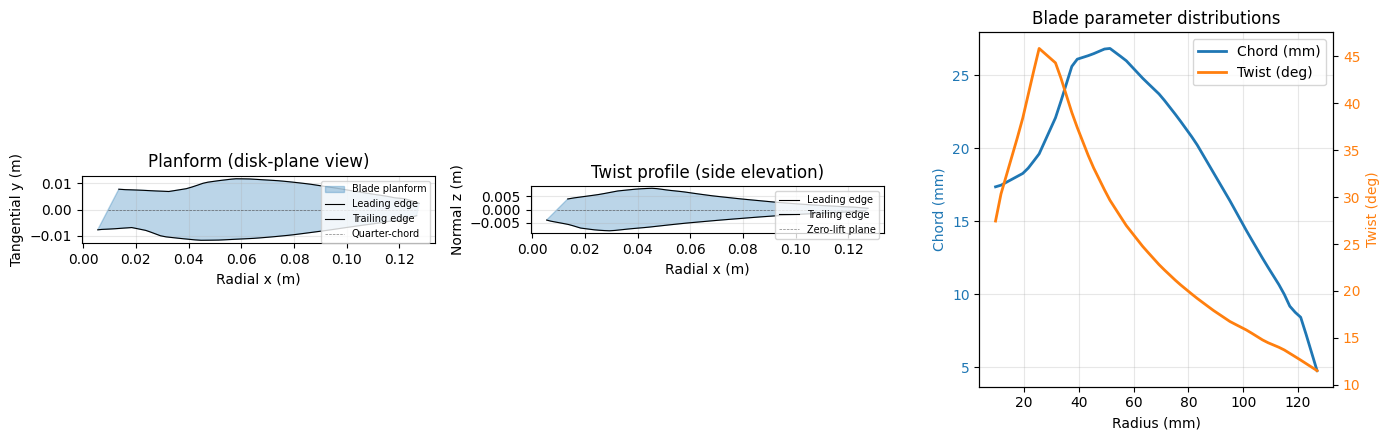

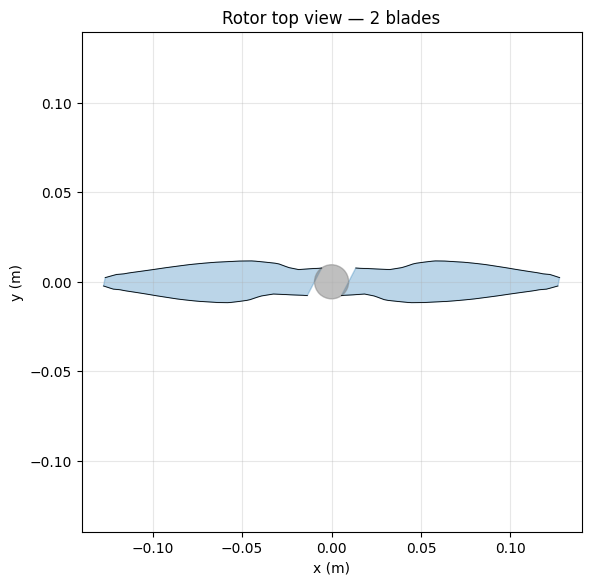

In [4]:
# Rotor geometry parameters
# Default: APC 10x7 Thin Electric propeller (real data from FLOWUnsteady / UIUC database)
# See: github.com/byuflowlab/FLOWUnsteady/tree/master/database/rotors
ROTOR_RADIUS_M = 0.127       # Blade tip radius in meters (10-inch prop = 0.127m)
HUB_RADIUS_M = 0.00953       # Hub radius in meters (APC 10x7 hub)
NUM_BLADES = 2               # Blades per rotor (2 for most drone props)
N_RADIAL = 60                # Number of radial panels (more = finer, slower)

# ------------------------------------------------------------------------------
# Real chord and twist distributions from APC 10x7 tabulated data
# ------------------------------------------------------------------------------
# Tabulated r/R, c/R (from FLOWUnsteady apc10x7_chorddist.csv)
_R_CHORD = np.array([
    0.0, 0.086, 0.16, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5,
    0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.9245, 0.954, 1.0
])
_C_R = np.array([
    0.134, 0.137106, 0.144606, 0.154291, 0.175, 0.205, 0.208, 0.212,
    0.205, 0.195, 0.186, 0.174, 0.161, 0.145, 0.129, 0.112, 0.096,
    0.081, 0.071125, 0.066125, 0.0375
])

# Tabulated r/R, twist (deg) (from FLOWUnsteady apc10x7_pitchdist.csv)
_R_TWIST = np.array([
    0.0, 0.04715, 0.088145, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45,
    0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0
])
_TWIST_DEG = np.array([
    17.0, 22.0, 30.0, 37.86, 45.82, 44.19, 38.35, 33.64, 29.9, 27.02,
    24.67, 22.62, 20.88, 19.36, 17.98, 16.74, 15.79, 14.64, 13.86,
    12.72, 11.53
])

# Convert normalized to absolute units
_r_chord_m = _R_CHORD * ROTOR_RADIUS_M
_c_m = _C_R * ROTOR_RADIUS_M
_r_twist_m = _R_TWIST * ROTOR_RADIUS_M

# Interpolators: callable functions that Blade() can use
# Must return torch tensors when input is a torch tensor (Blade uses torch internally)
def CHORD_M(r):
    if hasattr(r, 'detach'):
        import torch
        r_np = r.detach().cpu().numpy()
        c_np = np.interp(r_np, _r_chord_m, _c_m)
        return torch.from_numpy(c_np).to(r.dtype)
    return np.interp(r, _r_chord_m, _c_m)

def TWIST_DEG(r):
    if hasattr(r, 'detach'):
        import torch
        r_np = r.detach().cpu().numpy()
        t_np = np.interp(r_np, _r_twist_m, _TWIST_DEG)
        return torch.from_numpy(t_np).to(r.dtype)
    return np.interp(r, _r_twist_m, _TWIST_DEG)

# Observer position is already set in the cell above from DREGON geometry.
# (mic position minus rotor position in the drone frame)

# Atmospheric conditions
C0 = 343.0                   # Speed of sound (m/s)
RHO0 = 1.225                 # Air density (kg/m³)

# Simulation parameters
SIM_DURATION = None          # None = use full RPS duration; or set seconds
SIM_SR = 16000                # Internal simulation sample rate (Hz).
                             # Higher = better frequency resolution, slower.
                             # 8000 Hz captures up to 4 kHz (plenty for rotor noise).

print("Rotor geometry configured (APC 10x7 Thin Electric):")
print(f"  Radius: {ROTOR_RADIUS_M*1000:.1f} mm")
print(f"  Hub radius: {HUB_RADIUS_M*1000:.2f} mm")
print(f"  Chord at 75%R: {np.interp(0.75*ROTOR_RADIUS_M, _r_chord_m, _c_m)*1000:.1f} mm")
print(f"  Twist at 75%R: {np.interp(0.75*ROTOR_RADIUS_M, _r_twist_m, _TWIST_DEG):.1f}°")
print(f"  Blades: {NUM_BLADES}")
print(f"  Radial panels: {N_RADIAL}")
print(f"  Observer: {OBSERVER_POS.tolist()} m  (Mic {MIC_IDX} - Rotor {ROTOR_IDX})")
print(f"  Sim SR: {SIM_SR} Hz")

# Visualize blade geometry
blade_preview = Blade(
    radius=ROTOR_RADIUS_M,
    chord=CHORD_M,
    twist_deg=TWIST_DEG,
    hub_radius=HUB_RADIUS_M,
    n_radial=N_RADIAL,
)
rotor_preview = Rotor(blade=blade_preview, num_blades=NUM_BLADES)

fig_geom, _ = plot_blade_geometry(blade_preview)
plt.show()

fig_top, _ = plot_rotor_top_view(rotor_preview)
plt.show()


## 3. Build Simulator and Interpolate RPS

We interpolate the native RPS to the simulation time grid so the solver can evaluate rotor speed at any retarded time.

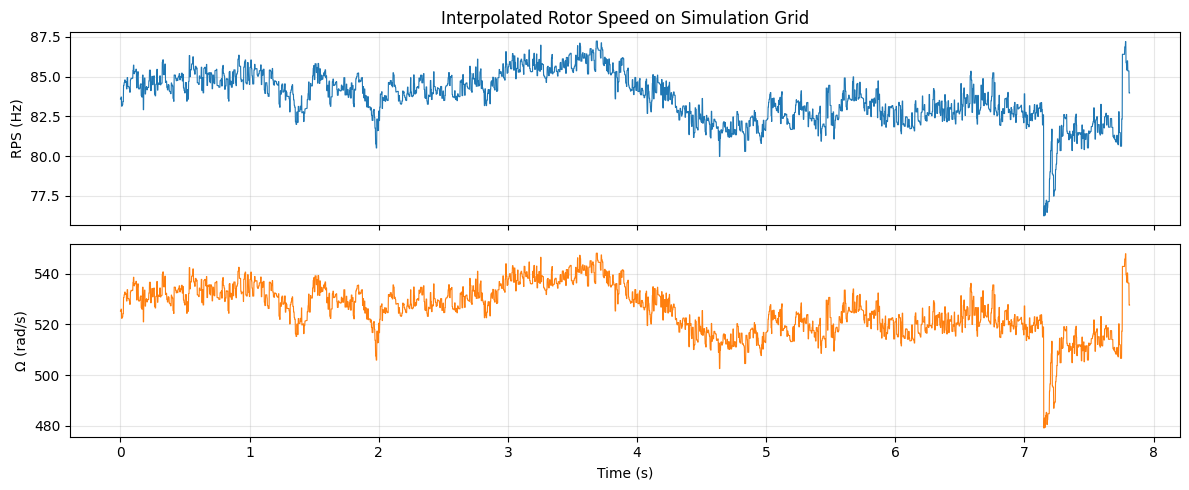

Simulation grid: 125024 points over 7.81s @ 16000 Hz


In [5]:
# Determine simulation duration
if SIM_DURATION is None:
    sim_duration = len(rps_native) / RPS_SR
else:
    sim_duration = min(SIM_DURATION, len(rps_native) / RPS_SR)

# Build simulation time grid
n_sim = int(sim_duration * SIM_SR)
t_sim = np.linspace(0, sim_duration, n_sim)

# Interpolate RPS to simulation grid
rps_interp = interp1d(
    t_native[:len(rps_native)],
    rps_native,
    kind='linear',
    fill_value='extrapolate',
)
rps_sim = rps_interp(t_sim)

# Convert RPS (Hz) to angular velocity Omega (rad/s)
omega_sim = rps_sim * 2.0 * np.pi
omega_sim_t = torch.from_numpy(omega_sim).float()
t_sim_t = torch.from_numpy(t_sim).float()

# Plot interpolated profile
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(t_sim, rps_sim, lw=0.8, color='C0')
axes[0].set_ylabel("RPS (Hz)")
axes[0].set_title("Interpolated Rotor Speed on Simulation Grid")
axes[0].grid(True, alpha=0.3)
axes[1].plot(t_sim, omega_sim, lw=0.8, color='C1')
axes[1].set_ylabel("Ω (rad/s)")
axes[1].set_xlabel("Time (s)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Simulation grid: {n_sim} points over {sim_duration:.2f}s @ {SIM_SR} Hz")

## 4. Run Acoustic Simulation

This computes the acoustic pressure at the observer using the FWH solver.
**Note:** This may take a while for long durations. Start with ~1-2 seconds.

In [6]:
# Build rotor and solver
blade = Blade(
    radius=ROTOR_RADIUS_M,
    chord=CHORD_M,
    twist_deg=TWIST_DEG,
    hub_radius=HUB_RADIUS_M,
    n_radial=N_RADIAL,
)
rotor = Rotor(blade=blade, num_blades=NUM_BLADES)
solver = FWHRotorSolver(rotor, c0=C0, rho0=RHO0)

# Precompute interpolation function (value-based, not index-based)
# This is important because retarded times can be earlier than t_sim[0]
_t_grid = t_sim
_omega_grid = omega_sim
def omega_func(tau):
    """Return Omega(tau) by linear interpolation from the pre-computed grid."""
    # tau may be 1D [N_t] or 2D [N_sources, N_t]
    tau_np = tau.detach().cpu().numpy().reshape(-1)
    omega_interp = np.interp(tau_np, _t_grid, _omega_grid)
    omega_t = torch.from_numpy(omega_interp).to(tau.dtype)
    return omega_t.reshape(tau.shape)

print("Running FWH acoustic simulation...")
print(f"  Duration: {sim_duration:.2f}s, grid: {n_sim} points")
print("  This may take a minute for long signals.")

# Run solver
with torch.no_grad():
    p = solver.compute_pressure(OBSERVER_POS, t_sim_t, omega_func)

print("\nSimulation complete!")
print(f"Pressure range: [{p.min():.6e}, {p.max():.6e}] Pa")
print(f"RMS pressure: {p.std():.6e} Pa")

Running FWH acoustic simulation...
  Duration: 7.81s, grid: 125024 points
  This may take a minute for long signals.

Simulation complete!
Pressure range: [-1.576246e+01, 1.206259e+01] Pa
RMS pressure: 5.565041e-01 Pa


## 5. Visualize Waveform and Spectrum

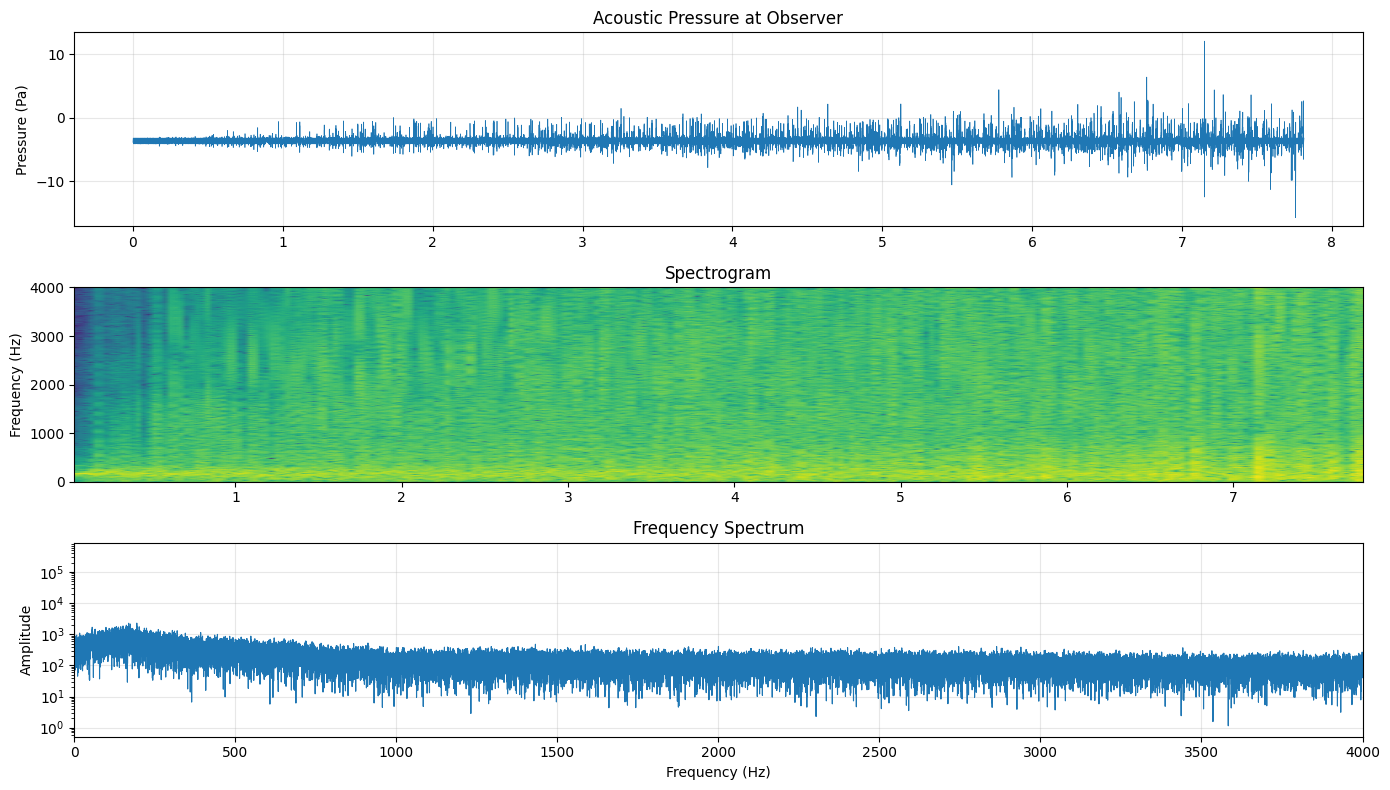

In [8]:
p_np = p.numpy()

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

# Waveform
ax = axes[0]
ax.plot(t_sim, p_np, lw=0.5)
ax.set_ylabel("Pressure (Pa)")
ax.set_title("Acoustic Pressure at Observer")
ax.grid(True, alpha=0.3)

# Spectrogram
ax = axes[1]
nperseg = min(1024, n_sim // 8)
from scipy.signal import spectrogram  # noqa: E402

f_spec, t_spec, Sxx = spectrogram(p_np, fs=SIM_SR, nperseg=nperseg, noverlap=nperseg//2)
ax.pcolormesh(t_spec, f_spec, 10*np.log10(Sxx + 1e-12), shading='gouraud', cmap='viridis')
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Spectrogram")
ax.set_ylim([0, min(4000, SIM_SR//2)])

# Spectrum
ax = axes[2]
from scipy.fft import rfft, rfftfreq  # noqa: E402

yf = rfft(p_np)
xf = rfftfreq(n_sim, 1/SIM_SR)
ax.semilogy(xf, np.abs(yf), lw=0.8)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Amplitude")
ax.set_title("Frequency Spectrum")
ax.set_xlim([0, min(4000, SIM_SR//2)])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Convert to Audio and Listen

The raw acoustic pressure is resampled to audio rate, high-pass filtered to remove DC, and normalized for playback.

Audio: 125024 samples @ 16000 Hz = 7.81s
Audio amplitude max: 0.900


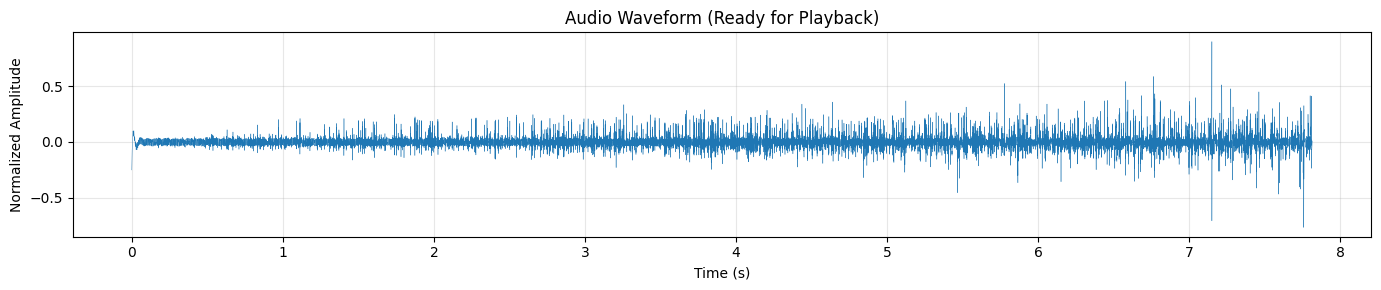


Playing generated rotor noise...



In [16]:
from scipy.signal import butter, resample_poly, sosfilt

# Step 1: High-pass filter to remove DC and very low frequencies (< 20 Hz)
# (Rotor noise is tonal; infrasound isn't audible anyway)
sos = butter(4, 20.0, btype='high', fs=SIM_SR, output='sos')
p_filtered = sosfilt(sos, p_np)

# Step 2: Resample from SIM_SR to AUDIO_SR
# Use resample_poly for clean rational resampling
gcd = np.gcd(SIM_SR, AUDIO_SR)
up = AUDIO_SR // gcd
down = SIM_SR // gcd
p_audio = resample_poly(p_filtered, up, down)

# Step 3: Normalize to prevent clipping
p_audio = p_audio / (np.max(np.abs(p_audio)) + 1e-12)
p_audio = p_audio * 0.9  # Leave some headroom

# Step 4: Convert to float32 for IPython Audio
p_audio = p_audio.astype(np.float32)

print(f"Audio: {len(p_audio)} samples @ {AUDIO_SR} Hz = {len(p_audio)/AUDIO_SR:.2f}s")
print(f"Audio amplitude max: {np.max(np.abs(p_audio)):.3f}")

# Plot audio waveform
t_audio = np.arange(len(p_audio)) / AUDIO_SR
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(t_audio, p_audio, lw=0.3)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Normalized Amplitude")
ax.set_title("Audio Waveform (Ready for Playback)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Play audio
print("\nPlaying generated rotor noise...\n")
ipd.display(ipd.Audio(p_audio, rate=AUDIO_SR))

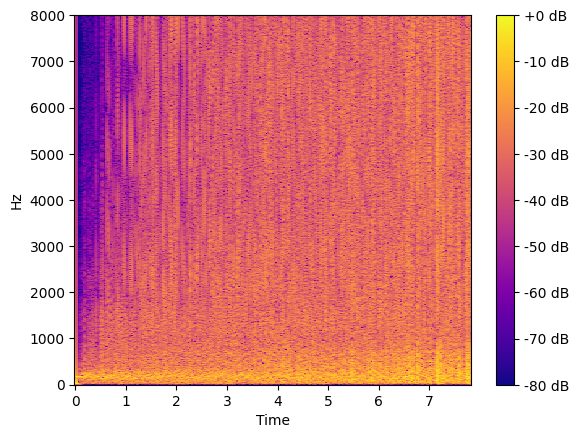

In [17]:
from utils import draw_spectrogram

draw_spectrogram(np.expand_dims(p_audio, 1), AUDIO_SR, 10.0, None)

In [16]:
SIM_SR


8000

## 7. Compare with Real Recording (if available)

If you loaded from DREGON-LM, compare the synthesized noise with the real recording.

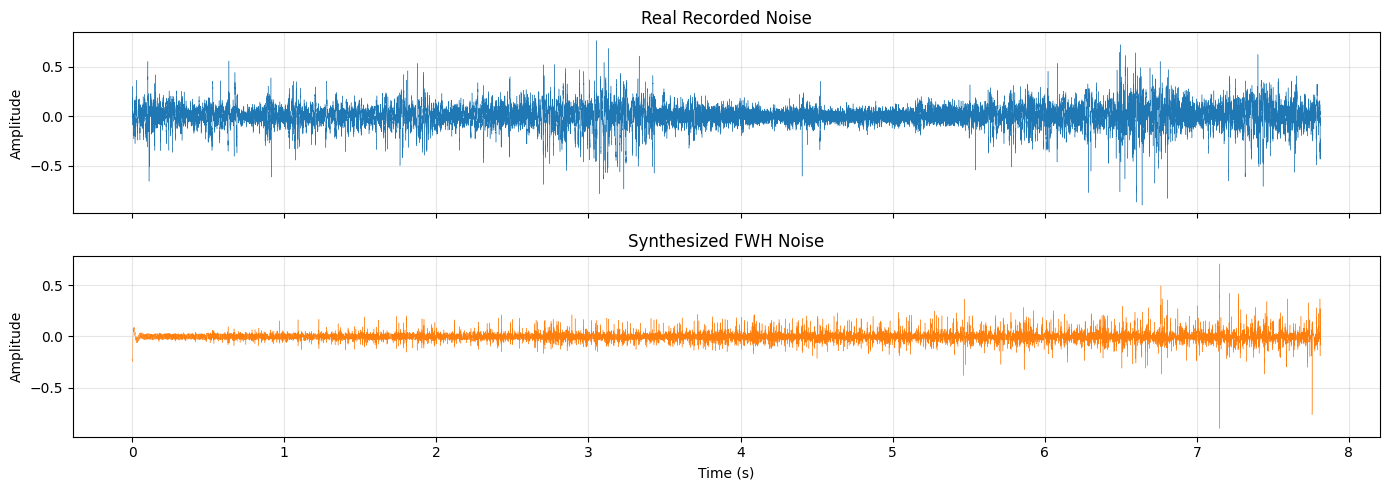

Real recording:



Synthesized noise:


In [9]:
noise_path = DATASET_PATH / SAMPLE_NAME / "noise.wav"
if noise_path.exists():
    import soundfile as sf
    real_noise, sr = sf.read(noise_path)

    # Trim to same duration
    n_samples = int(sim_duration * sr)
    real_noise = real_noise[:n_samples]

    # Normalize both
    real_norm = real_noise / (np.max(np.abs(real_noise)) + 1e-12) * 0.9
    synth_norm = p_audio[:len(real_norm)] if len(p_audio) > len(real_norm) else np.pad(
        p_audio, (0, len(real_norm) - len(p_audio))
    )

    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
    t_real = np.arange(len(real_norm)) / sr
    axes[0].plot(t_real, real_norm, lw=0.3, color='C0')
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title("Real Recorded Noise")
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(t_real, synth_norm, lw=0.3, color='C1')
    axes[1].set_ylabel("Amplitude")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_title("Synthesized FWH Noise")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Real recording:")
    ipd.display(ipd.Audio(real_norm, rate=sr))
    print("\nSynthesized noise:")
    ipd.display(ipd.Audio(synth_norm, rate=AUDIO_SR))
else:
    print(f"No real recording found at {noise_path}")

---

## Appendix: Parameter Sweep (Optional)

Quickly compare how rotor geometry affects the sound.

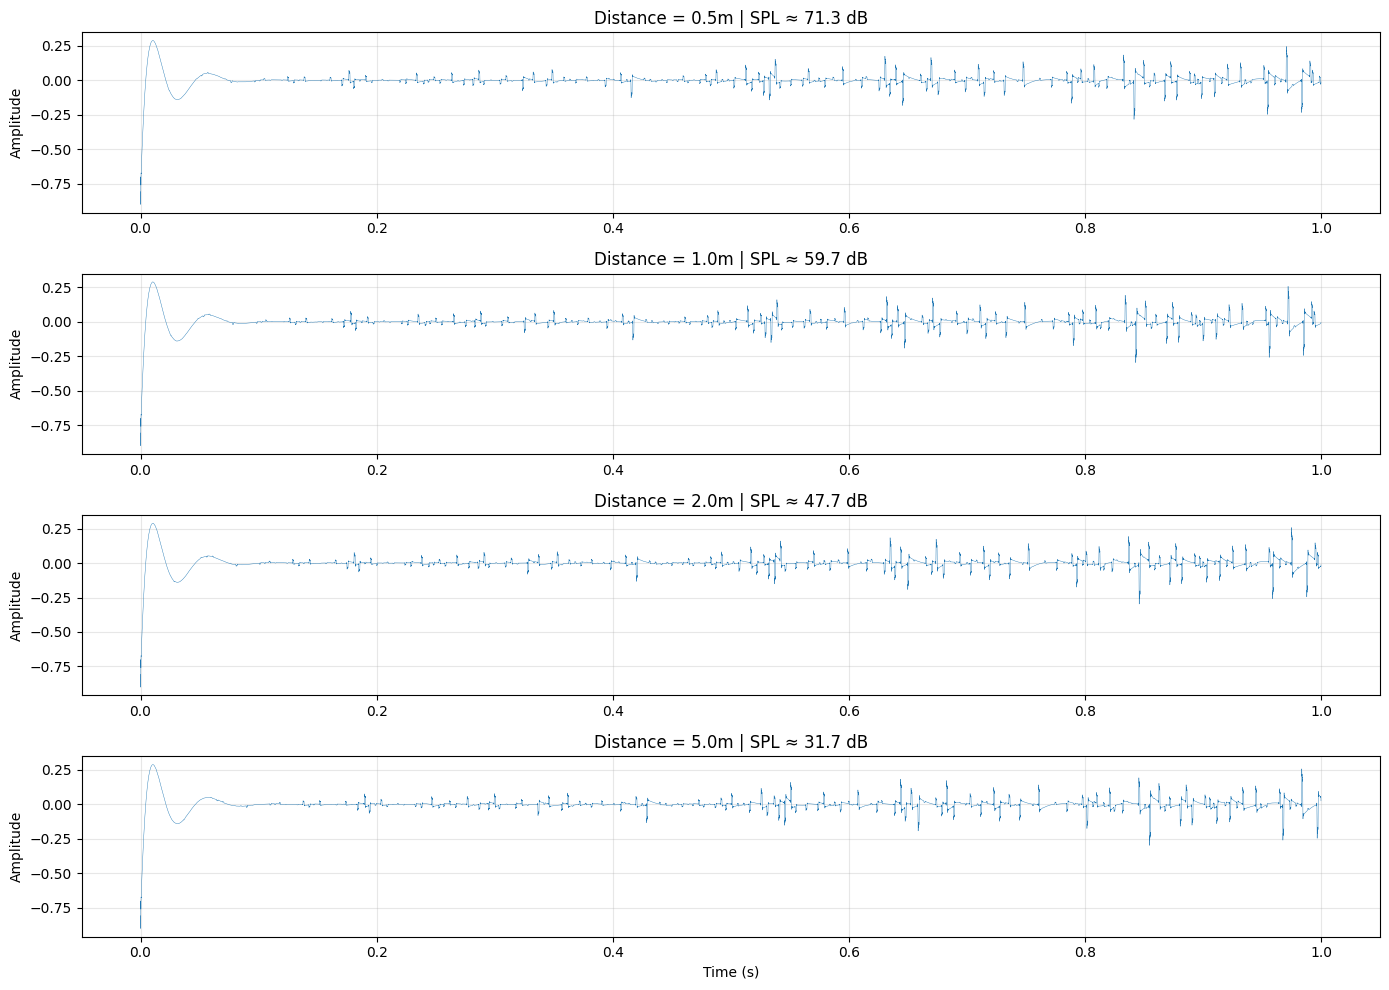


Distance = 0.5m:



Distance = 1.0m:



Distance = 2.0m:



Distance = 5.0m:


In [10]:
# Quick comparison: different observer distances
distances = [0.5, 1.0, 2.0, 5.0]

# Use a short clip for speed
short_duration = 1.0
n_short = int(short_duration * SIM_SR)
t_short = t_sim_t[:n_short]
omega_short = omega_sim_t[:n_short]

_t_short = t_sim[:n_short]
_omega_short = omega_sim[:n_short]
def omega_short_func(tau):
    tau_np = tau.detach().cpu().numpy().reshape(-1)
    oi = np.interp(tau_np, _t_short, _omega_short)
    return torch.from_numpy(oi).to(tau.dtype).reshape(tau.shape)

fig, axes = plt.subplots(len(distances), 1, figsize=(14, 2.5*len(distances)))
if len(distances) == 1:
    axes = [axes]

audios = []
for i, dist in enumerate(distances):
    obs = torch.tensor([0.0, 0.0, -dist])
    with torch.no_grad():
        p_d = solver.compute_pressure(obs, t_short, omega_short_func)

    # High-pass, resample, normalize
    p_d_np = p_d.numpy()
    p_d_filt = sosfilt(sos, p_d_np)
    p_d_audio = resample_poly(p_d_filt, up, down)
    p_d_audio = (p_d_audio / (np.max(np.abs(p_d_audio)) + 1e-12)) * 0.9
    p_d_audio = p_d_audio.astype(np.float32)
    audios.append(p_d_audio)

    t_a = np.arange(len(p_d_audio)) / AUDIO_SR
    axes[i].plot(t_a, p_d_audio, lw=0.3)
    axes[i].set_title(f"Distance = {dist}m | SPL ≈ {20*np.log10(p_d_np.std()/20e-6):.1f} dB")
    axes[i].set_ylabel("Amplitude")
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

for dist, aud in zip(distances, audios):
    print(f"\nDistance = {dist}m:")
    ipd.display(ipd.Audio(aud, rate=AUDIO_SR))

In [20]:
ind_recording, sr = sf.read(str(get_data_path("DREGON/DREGON_individual_motors_recordings/Motor1_90.wav")))

NameError: name 'sf' is not defined

In [21]:
ind_recording.shape

NameError: name 'ind_recording' is not defined

In [22]:
from utils import draw_spectrogram

In [19]:
ipd.display(ipd.Audio(ind_recording[:, 0], rate=sr))

NameError: name 'ind_recording' is not defined

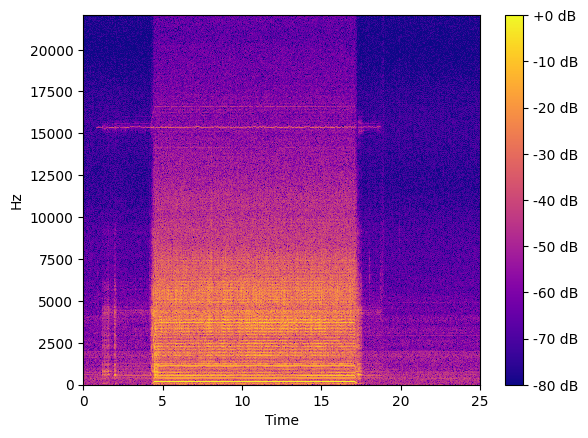

In [15]:
draw_spectrogram(ind_recording[:, 0:1], sr, 25.0, None)

Constant-speed simulation:
  RPS: 90.0 Hz
  Omega: 565.49 rad/s
  BPF: 180.0 Hz  (blade passing frequency)
  Duration: 4.0 s  (64000 samples @ 16000 Hz)
  Observer (Mic 0 - Rotor 0): [0.20197339355945587, -0.10997339338064194, -0.23250000178813934]

Simulation complete!
Pressure range: [-4.807576e+00, -3.697819e+00] Pa
RMS pressure: 3.886887e-01 Pa


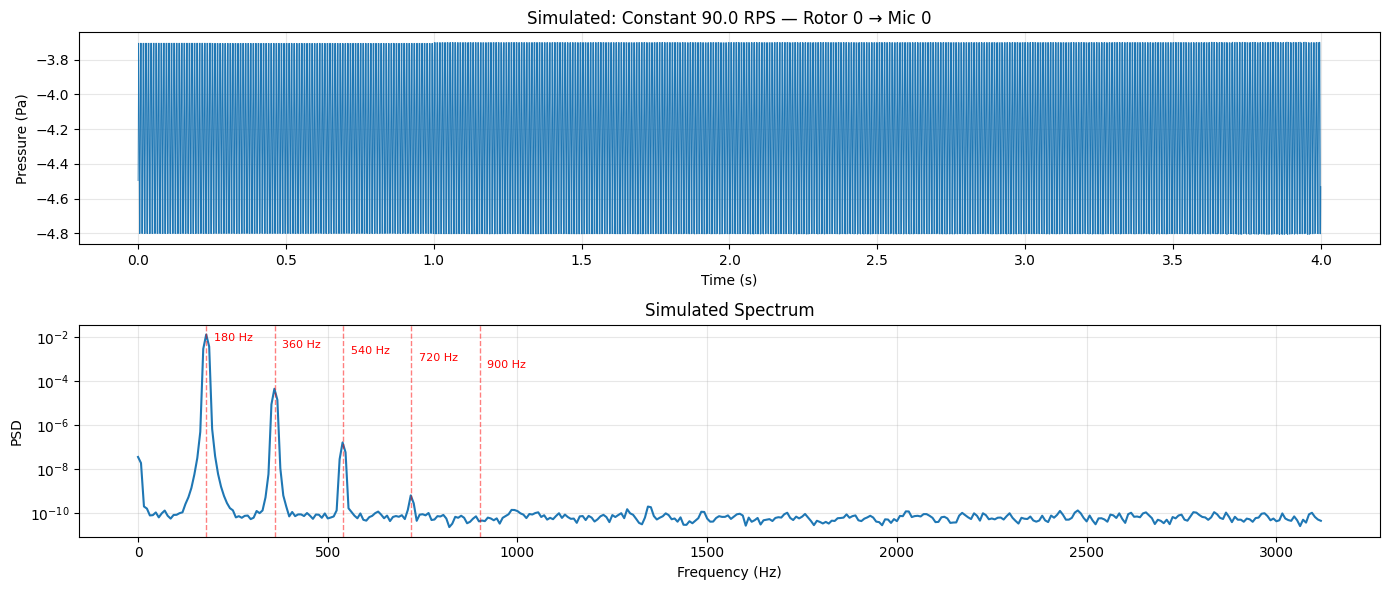

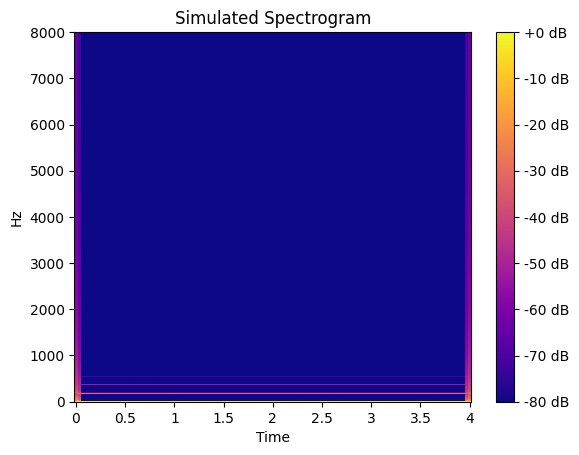


Audio: 4.00s @ 16000 Hz


In [42]:
# ------------------------------------------------------------------------------
# Constant-speed simulation: Rotor 0 at 90 RPS, observed by Mic 0
# ------------------------------------------------------------------------------
# This uses the same geometry already configured above, but with a constant
# rotor speed instead of an RPS timeseries.

RPS_CONSTANT = 90.0          # Constant rotor speed (Hz = revolutions per second)
DURATION_CS = 4.0            # Simulation duration in seconds
SIM_SR_CS = 16000             # Simulation sample rate (Hz)

# Time grid
t_cs = np.arange(0, DURATION_CS, 1.0 / SIM_SR_CS)
n_cs = len(t_cs)

# Constant angular velocity: Omega = 2 * pi * RPS
omega_constant = 2.0 * np.pi * RPS_CONSTANT

print("Constant-speed simulation:")
print(f"  RPS: {RPS_CONSTANT} Hz")
print(f"  Omega: {omega_constant:.2f} rad/s")
print(f"  BPF: {RPS_CONSTANT * NUM_BLADES:.1f} Hz  (blade passing frequency)")
print(f"  Duration: {DURATION_CS} s  ({n_cs} samples @ {SIM_SR_CS} Hz)")
print(f"  Observer (Mic {MIC_IDX} - Rotor {ROTOR_IDX}): {OBSERVER_POS.tolist()}")

# Re-use the solver already built (or rebuild if needed)
try:
    _ = solver
except NameError:
    blade = Blade(
        radius=ROTOR_RADIUS_M,
        chord=CHORD_M,
        twist_deg=TWIST_DEG,
        hub_radius=HUB_RADIUS_M,
        n_radial=N_RADIAL,
    )
    rotor = Rotor(blade=blade, num_blades=NUM_BLADES)
    solver = FWHRotorSolver(rotor, c0=C0, rho0=RHO0)

# Constant omega function: returns constant for any tau
def omega_func_cs(tau):
    """Constant angular velocity."""
    return torch.full_like(tau, omega_constant)

# Run simulation
t_cs_t = torch.tensor(t_cs, dtype=torch.float32)
with torch.no_grad():
    p_cs = solver.compute_pressure(OBSERVER_POS, t_cs_t, omega_func_cs)

print("\nSimulation complete!")
print(f"Pressure range: [{p_cs.min():.6e}, {p_cs.max():.6e}] Pa")
print(f"RMS pressure: {p_cs.std():.6e} Pa")

# --- Waveform + Spectrum (2-panel) ---
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Waveform
ax = axes[0]
ax.plot(t_cs, p_cs.numpy(), lw=0.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Pressure (Pa)")
ax.set_title(f"Simulated: Constant {RPS_CONSTANT} RPS — Rotor 0 → Mic 0")
ax.grid(True, alpha=0.3)

# Spectrum
ax = axes[1]
from scipy.signal import welch  # noqa: E402

freqs, psd = welch(p_cs.numpy(), fs=SIM_SR_CS, nperseg=2048)
ax.semilogy(freqs[:400], psd[:400])
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD")
ax.set_title("Simulated Spectrum")
for harmonic in range(1, 6):
    bpf_h = RPS_CONSTANT * NUM_BLADES * harmonic
    if bpf_h < freqs[:400].max():
        ax.axvline(bpf_h, color="r", ls="--", alpha=0.5, lw=1)
        ax.text(bpf_h + 20, psd.max() * 0.5**harmonic, f"{bpf_h:.0f} Hz", color="r", fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Spectrogram via draw_spectrogram ---
from utils import draw_spectrogram  # noqa: E402

p_cs_for_spec = np.expand_dims(p_cs.numpy(), axis=1)
draw_spectrogram(p_cs_for_spec, SIM_SR_CS, DURATION_CS, output_file=None)
plt.title("Simulated Spectrogram")
plt.show()

# --- Convert to audio ---
AUDIO_SR_CS = 16000
p_audio_cs = resample_poly(p_cs.numpy(), AUDIO_SR_CS, SIM_SR_CS)

# High-pass filter
sos = butter(4, 20.0, btype="high", fs=AUDIO_SR_CS, output="sos")
p_audio_cs = sosfilt(sos, p_audio_cs)

# Normalize
p_audio_cs = p_audio_cs / np.max(np.abs(p_audio_cs)) * 0.9

print(f"\nAudio: {len(p_audio_cs)/AUDIO_SR_CS:.2f}s @ {AUDIO_SR_CS} Hz")
ipd.display(ipd.Audio(p_audio_cs, rate=AUDIO_SR_CS))


Loaded real recording: (1102500, 8) @ 44100 Hz
Clipped 6.0-10.0s: (176400, 8)


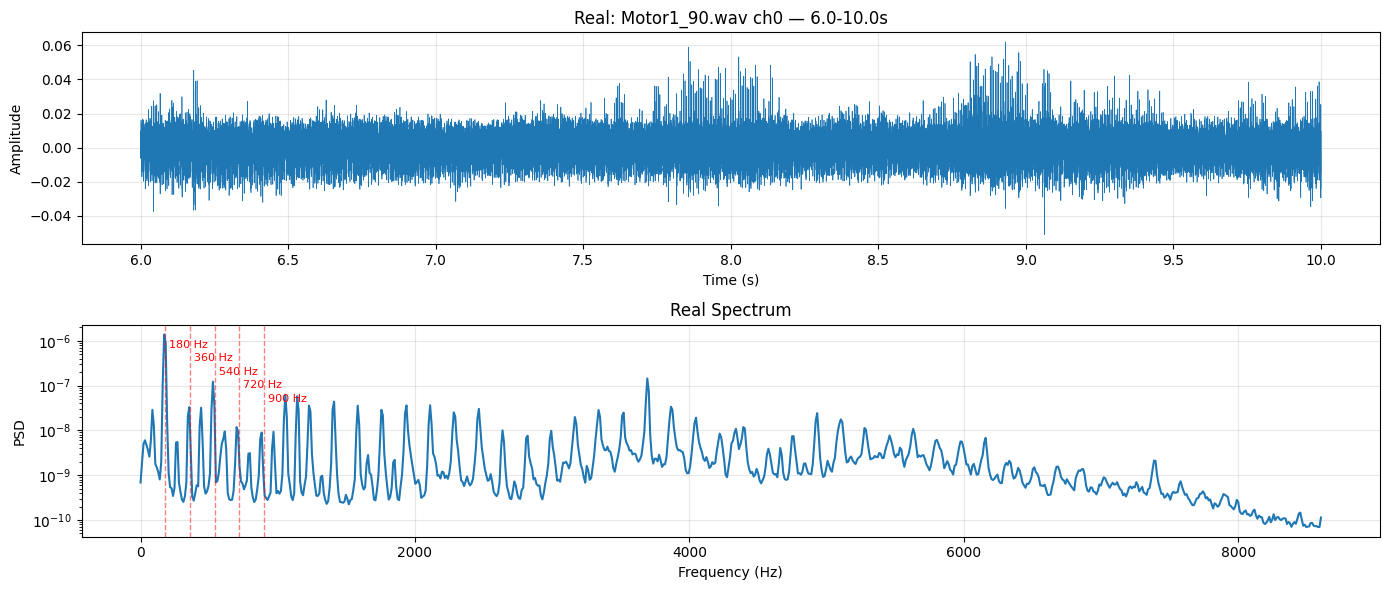

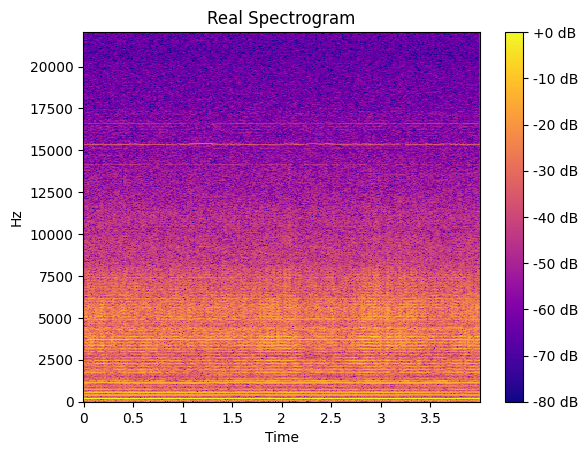

In [43]:
# ------------------------------------------------------------------------------
# Real recording: Motor 1 at 90 RPS, seconds 6–10
# ------------------------------------------------------------------------------
# Load the actual DREGON individual motor recording and compare with simulation.

import soundfile as sf

MOTOR90_PATH = PROJECT_ROOT / "data" / "DREGON" / "DREGON_individual_motors_recordings" / "Motor1_90.wav"
ind_recording, sr_real = sf.read(str(MOTOR90_PATH))

print(f"Loaded real recording: {ind_recording.shape} @ {sr_real} Hz")

# Cut seconds 6 to 10
t_start = 6.0
t_end = 10.0
start_idx = int(t_start * sr_real)
end_idx = int(t_end * sr_real)
real_clip = ind_recording[start_idx:end_idx, :]   # (samples, 8 channels)

print(f"Clipped {t_start}-{t_end}s: {real_clip.shape}")

# Use channel 0 (corresponds to Mic 0 in the array)
real_ch0 = real_clip[:, 0]

# --- Waveform + Spectrum (2-panel) ---
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

t_real = np.linspace(t_start, t_end, len(real_ch0))

# Waveform
ax = axes[0]
ax.plot(t_real, real_ch0, lw=0.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f"Real: Motor1_90.wav ch0 — {t_start}-{t_end}s")
ax.grid(True, alpha=0.3)

# Spectrum
ax = axes[1]
from scipy.signal import welch  # noqa: E402

freqs_r, psd_r = welch(real_ch0, fs=sr_real, nperseg=4096)
ax.semilogy(freqs_r[:800], psd_r[:800])
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD")
ax.set_title("Real Spectrum")
for harmonic in range(1, 6):
    bpf_h = RPS_CONSTANT * NUM_BLADES * harmonic
    if bpf_h < freqs_r[:800].max():
        ax.axvline(bpf_h, color="r", ls="--", alpha=0.5, lw=1)
        ax.text(bpf_h + 30, psd_r.max() * 0.5**harmonic, f"{bpf_h:.0f} Hz", color="r", fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Spectrogram via draw_spectrogram ---
from utils import draw_spectrogram  # noqa: E402

real_for_spec = np.expand_dims(real_ch0, axis=1)
draw_spectrogram(real_for_spec, sr_real, t_end - t_start, output_file=None)
plt.title("Real Spectrogram")
plt.show()

# --- Play audio ---
ipd.display(ipd.Audio(real_ch0, rate=sr_real))


Loaded real recording: (1102500, 8) @ 44100 Hz
Clipped 6.0-10.0s: (176400, 8)


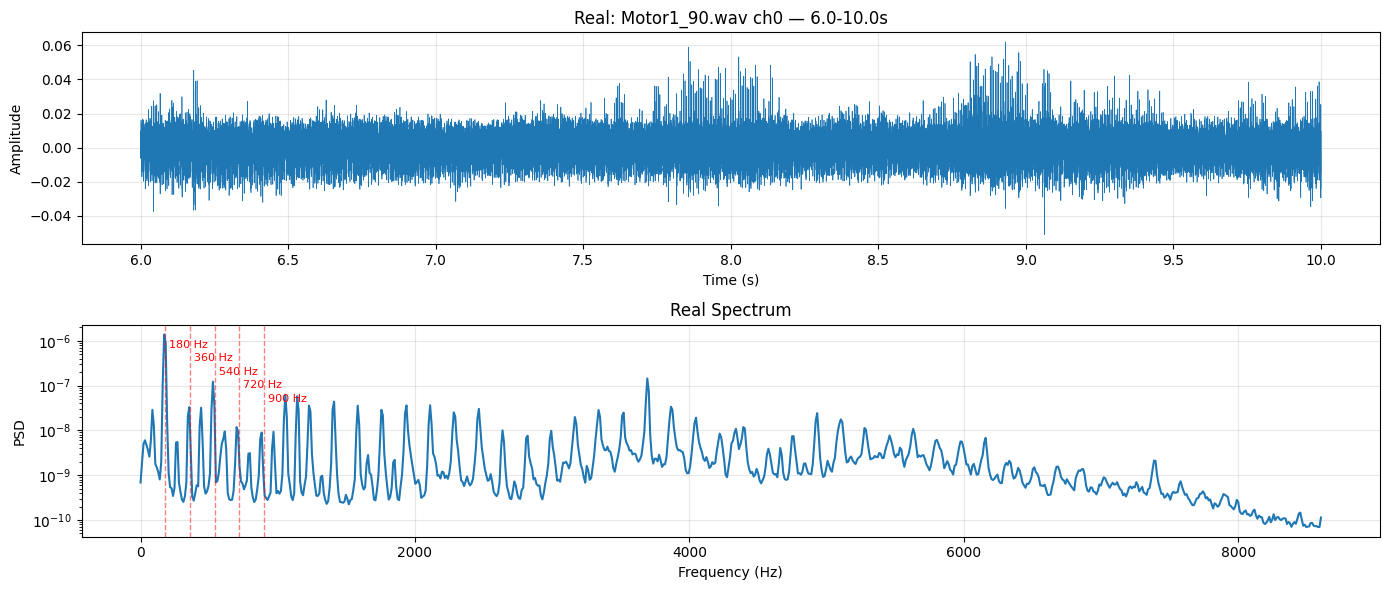

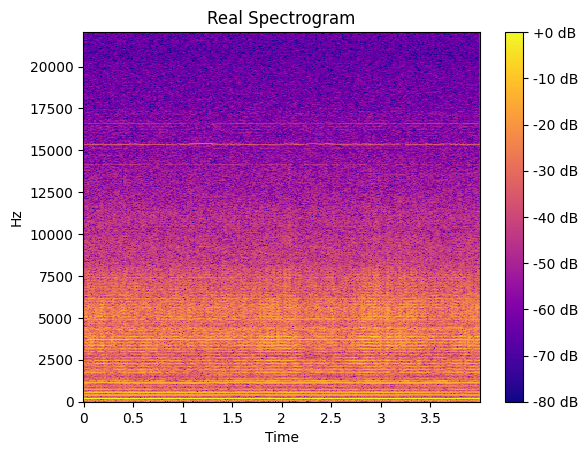

In [44]:
# ------------------------------------------------------------------------------
# Real recording: Motor 1 at 90 RPS, seconds 6–10
# ------------------------------------------------------------------------------
# Load the actual DREGON individual motor recording and compare with simulation.

import soundfile as sf

MOTOR90_PATH = PROJECT_ROOT / "data" / "DREGON" / "DREGON_individual_motors_recordings" / "Motor1_90.wav"
ind_recording, sr_real = sf.read(str(MOTOR90_PATH))

print(f"Loaded real recording: {ind_recording.shape} @ {sr_real} Hz")

# Cut seconds 6 to 10
t_start = 6.0
t_end = 10.0
start_idx = int(t_start * sr_real)
end_idx = int(t_end * sr_real)
real_clip = ind_recording[start_idx:end_idx, :]   # (samples, 8 channels)

print(f"Clipped {t_start}-{t_end}s: {real_clip.shape}")

# Use channel 0 (corresponds to Mic 0 in the array)
real_ch0 = real_clip[:, 0]

# --- Waveform + Spectrum (2-panel) ---
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

t_real = np.linspace(t_start, t_end, len(real_ch0))

# Waveform
ax = axes[0]
ax.plot(t_real, real_ch0, lw=0.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f"Real: Motor1_90.wav ch0 — {t_start}-{t_end}s")
ax.grid(True, alpha=0.3)

# Spectrum
ax = axes[1]
from scipy.signal import welch  # noqa: E402

freqs_r, psd_r = welch(real_ch0, fs=sr_real, nperseg=4096)
ax.semilogy(freqs_r[:800], psd_r[:800])
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD")
ax.set_title("Real Spectrum")
for harmonic in range(1, 6):
    bpf_h = RPS_CONSTANT * NUM_BLADES * harmonic
    if bpf_h < freqs_r[:800].max():
        ax.axvline(bpf_h, color="r", ls="--", alpha=0.5, lw=1)
        ax.text(bpf_h + 30, psd_r.max() * 0.5**harmonic, f"{bpf_h:.0f} Hz", color="r", fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Spectrogram via draw_spectrogram ---
from utils import draw_spectrogram  # noqa: E402

real_for_spec = np.expand_dims(real_ch0, axis=1)
draw_spectrogram(real_for_spec, sr_real, t_end - t_start, output_file=None)
plt.title("Real Spectrogram")
plt.show()

# --- Play audio ---
ipd.display(ipd.Audio(real_ch0, rate=sr_real))
